In [24]:
# --- Core data libraries ---
import numpy as np
import pandas as pd

# --- Visualisation libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display settings ---
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Random seed set to 42 — all results are reproducible.")

All libraries imported successfully.
NumPy version: 2.4.3
Pandas version: 3.0.1
Random seed set to 42 — all results are reproducible.


# MTN NIGERIA PREPAID CHURN PREDICTION
     Phase 1 — Data Generation & Exploratory Data Analysis
     Author: Elijjjaaaahhhhh
     Dataset: NGA_MTN_Subscribers_500K (synthetic)
     Seed: 42 (all random operations use this seed for reproducibility)

In [25]:
# CELL 2 — DATASET PARAMETERS
# Define all constants that control dataset generation.

# --- Scale ---
N_SUBSCRIBERS = 500_000       # Total number of rows to generate
N_MONTHS      = 36            # Jan 2022 – Dec 2024

# --- Churn rate ---
BASE_MONTHLY_CHURN_RATE = 0.05   # 5% monthly churn (~25,000 churners)

# --- Nigerian states (36 states + FCT = 37 total) ---
NIGERIAN_STATES = [
    'Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa',
    'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo',
    'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano',
    'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger',
    'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto',
    'Taraba', 'Yobe', 'Zamfara', 'FCT Abuja'
]

# --- States with higher churn (more competition, higher income) ---
HIGH_CHURN_STATES = ['Lagos', 'Kano', 'FCT Abuja', 'Rivers', 'Enugu']

# --- MTN Nigeria tariff plans ---
TARIFF_PLANS = ['MTNPulse', 'BetaGist', 'XtraValue', 'XtraSpecial', 'mPulse']

# --- Tariff plan weights (how common each plan is in the subscriber base) ---
# TalkMore is the most common prepaid plan
# SMEBundle is least common — it targets small businesses
TARIFF_WEIGHTS = [0.35, 0.15, 0.25, 0.15, 0.10]  # Must sum to 1.0

# --- State distribution weights ---
# Lagos, Kano, and Abuja have the largest subscriber bases
# We build this dynamically so every state gets a weight
STATE_WEIGHTS = []
for state in NIGERIAN_STATES:
    if state == 'Lagos':
        STATE_WEIGHTS.append(0.18)      # Lagos alone = 18% of subscribers
    elif state == 'Kano':
        STATE_WEIGHTS.append(0.07)      # Kano = 7%
    elif state == 'FCT Abuja':
        STATE_WEIGHTS.append(0.10)      # Abuja = 10%
    elif state == 'Rivers':
        STATE_WEIGHTS.append(0.06)      # Rivers = 6%
    elif state == 'Enugu':
        STATE_WEIGHTS.append(0.06)      # Enugu = 6%
    else:
        # Remaining 32 states share the remaining 53%
        STATE_WEIGHTS.append(0.53 / 32)

# Confirm weights sum to 1.0 (they must — this is a probability distribution)
assert round(sum(STATE_WEIGHTS), 6) == 1.0, "State weights must sum to 1.0"

# --- Observation months ---
import pandas as pd
OBSERVATION_MONTHS = pd.date_range(start='2022-01-01', periods=N_MONTHS, freq='MS')
# 'MS' = Month Start — generates the first day of each month

# --- Print confirmation ---
print(f"Dataset parameters defined.")
print(f"Total subscribers     : {N_SUBSCRIBERS:,}")
print(f"Observation period    : {OBSERVATION_MONTHS[0].strftime('%b %Y')} to {OBSERVATION_MONTHS[-1].strftime('%b %Y')}")
print(f"Number of months      : {N_MONTHS}")
print(f"Base monthly churn    : {BASE_MONTHLY_CHURN_RATE*100:.0f}%")
print(f"Number of states      : {len(NIGERIAN_STATES)}")
print(f"Tariff plans          : {TARIFF_PLANS}")
print(f"State weights sum     : {sum(STATE_WEIGHTS):.6f} ✓")


Dataset parameters defined.
Total subscribers     : 500,000
Observation period    : Jan 2022 to Dec 2024
Number of months      : 36
Base monthly churn    : 5%
Number of states      : 37
Tariff plans          : ['MTNPulse', 'BetaGist', 'XtraValue', 'XtraSpecial', 'mPulse']
State weights sum     : 1.000000 ✓


## DATASET GENERATION
    Generates 500,000 synthetic MTN Nigeria subscriber rows.
    Schema: 21 columns

In [26]:

# ARCHITECTURE: Behaviour-First Segment Inference
#   Raw behaviour generated using seed segment distributions.
#   Segment label INFERRED from actual behaviour scores.
#   Normalisation uses realistic engaged benchmarks not maximums.
#
# THREE SEGMENTS (inferred):
#   Traditional (~31%) — voice-first, USSD, scratch card
#   Digital     (~47%) — data-first, app, bank transfer
#   Hybrid      (~22%) — fluid, context-dependent
#
# 20 CHURN SIGNALS:
#   Shared | Traditional-specific | Digital-specific | Hybrid-specific
#
# USSD codes (NCC-harmonised May 2023):
#   *310# = airtime balance  | *323# = data balance
#   *312# = buy data bundle  | *303# = borrow airtime
# ============================================================

def generate_mtn_dataset(n_subscribers, random_seed=42):
    """
    Generates a synthetic MTN Nigeria prepaid subscriber dataset.

    INPUT:
        n_subscribers (int): Number of rows to generate
        random_seed   (int): Seed for reproducibility

    OUTPUT:
        pandas DataFrame with 21 columns and n_subscribers rows
    """

    np.random.seed(random_seed)
    print(f"Generating {n_subscribers:,} subscriber records...")
    print("This may take 45-90 seconds. Please wait.")

    # --------------------------------------------------------
    # SECTION 1 — SUBSCRIBER IDs AND OBSERVATION MONTHS
    # --------------------------------------------------------

    subscriber_ids = [
        f"MTN-{np.random.randint(10000000, 99999999)}"
        for _ in range(n_subscribers)
    ]

    observation_months = np.random.choice(
        OBSERVATION_MONTHS, size=n_subscribers
    )

    # --------------------------------------------------------
    # SECTION 2 — STATE AND TARIFF PLAN
    # Assigned first — needed for channel and churn logic
    # --------------------------------------------------------

    states = np.random.choice(
        NIGERIAN_STATES,
        size=n_subscribers,
        p=STATE_WEIGHTS
    )

    tariff_plans = np.random.choice(
        TARIFF_PLANS,
        size=n_subscribers,
        p=TARIFF_WEIGHTS
    )

    is_urban_state = np.isin(states, HIGH_CHURN_STATES)

    # --------------------------------------------------------
    # SECTION 3 — SEED SEGMENT ASSIGNMENT
    # Generation seed only — NOT the final label.
    # Final segment is inferred from behaviour scores.
    # Seed: Traditional 38% | Digital 52% | Hybrid 10%
    # After inference, Hybrid grows to ~22% as boundary
    # subscribers migrate naturally from both segments.
    # --------------------------------------------------------

    seed_segment = np.random.choice(
        ['Traditional', 'Digital', 'Hybrid'],
        size=n_subscribers,
        p=[0.38, 0.52, 0.10]
    )

    is_seed_trad   = (seed_segment == 'Traditional')
    is_seed_dig    = (seed_segment == 'Digital')
    is_seed_hybrid = (seed_segment == 'Hybrid')

    # --------------------------------------------------------
    # SECTION 4 — TENURE
    # Traditional: loc=48 | Digital: loc=24 | Hybrid: loc=36
    # --------------------------------------------------------

    tenure_months = np.where(
        is_seed_trad,
        np.clip(
            np.random.normal(
                loc=48, scale=24, size=n_subscribers
            ).astype(int), 1, 120
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.normal(
                    loc=24, scale=18, size=n_subscribers
                ).astype(int), 1, 120
            ),
            np.clip(
                np.random.normal(
                    loc=36, scale=20, size=n_subscribers
                ).astype(int), 1, 120
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 5 — DAYS SINCE LAST RECHARGE
    # Traditional: scale=18 | Digital: scale=12 | Hybrid: scale=15
    # --------------------------------------------------------

    days_since_last_recharge = np.where(
        is_seed_trad,
        np.clip(
            np.random.exponential(
                scale=18, size=n_subscribers
            ).astype(int), 0, 90
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.exponential(
                    scale=12, size=n_subscribers
                ).astype(int), 0, 90
            ),
            np.clip(
                np.random.exponential(
                    scale=15, size=n_subscribers
                ).astype(int), 0, 90
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 6 — RECHARGE FREQUENCY
    # Traditional: lam=6 | Digital: lam=4 | Hybrid: lam=5
    # --------------------------------------------------------

    recharge_frequency_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.poisson(lam=6, size=n_subscribers), 0, 30
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.poisson(lam=4, size=n_subscribers), 0, 30
            ),
            np.clip(
                np.random.poisson(lam=5, size=n_subscribers), 0, 30
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 7 — AVERAGE RECHARGE VALUE
    # Traditional: mass ₦250 (90%) | high ₦800 (10%)
    # Digital:     mass ₦800 (80%) | high ₦2500 (20%)
    # Hybrid:      mass ₦500 (75%) | high ₦1500 (25%)
    # --------------------------------------------------------

    trad_mass     = np.random.normal(loc=250,  scale=100, size=n_subscribers)
    trad_high     = np.random.normal(loc=800,  scale=200, size=n_subscribers)
    trad_hflag    = np.random.binomial(1, 0.10, size=n_subscribers)
    trad_recharge = np.where(trad_hflag == 1, trad_high, trad_mass)

    dig_mass      = np.random.normal(loc=800,  scale=300, size=n_subscribers)
    dig_high      = np.random.normal(loc=2500, scale=800, size=n_subscribers)
    dig_hflag     = np.random.binomial(1, 0.20, size=n_subscribers)
    dig_recharge  = np.where(dig_hflag == 1, dig_high, dig_mass)

    hyb_mass      = np.random.normal(loc=500,  scale=200, size=n_subscribers)
    hyb_high      = np.random.normal(loc=1500, scale=500, size=n_subscribers)
    hyb_hflag     = np.random.binomial(1, 0.25, size=n_subscribers)
    hyb_recharge  = np.where(hyb_hflag == 1, hyb_high, hyb_mass)

    avg_recharge_value_naira = np.where(
        is_seed_trad, trad_recharge,
        np.where(is_seed_dig, dig_recharge, hyb_recharge)
    )
    avg_recharge_value_naira = np.clip(
        avg_recharge_value_naira, 50, 5000
    ).round(2)

    # --------------------------------------------------------
    # SECTION 8 — USSD SESSIONS
    # Traditional: lam=30 | Digital: lam=8 | Hybrid: lam=18
    # --------------------------------------------------------

    ussd_sessions_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.poisson(lam=30, size=n_subscribers), 0, 200
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.poisson(lam=8, size=n_subscribers), 0, 200
            ),
            np.clip(
                np.random.poisson(lam=18, size=n_subscribers), 0, 200
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 9 — APP SESSIONS
    # Traditional: lam=0.5 | Digital: lam=12 | Hybrid: lam=7
    # --------------------------------------------------------

    app_sessions_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.poisson(lam=0.5, size=n_subscribers), 0, 5
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.poisson(lam=12, size=n_subscribers), 0, 50
            ),
            np.clip(
                np.random.poisson(lam=7, size=n_subscribers), 0, 50
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 10 — DATA CONSUMPTION
    # Traditional: 0-2,000MB  | scale=300
    # Digital:     0-50,000MB | scale=6000
    # Hybrid:      0-15,000MB | scale=2000
    # --------------------------------------------------------

    data_mb_consumed_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.exponential(
                scale=300, size=n_subscribers
            ).round(2), 0, 2000
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.exponential(
                    scale=6000, size=n_subscribers
                ).round(2), 0, 50000
            ),
            np.clip(
                np.random.exponential(
                    scale=2000, size=n_subscribers
                ).round(2), 0, 15000
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 11 — VOICE MINUTES
    # Traditional: loc=300 | Digital: loc=100 | Hybrid: loc=200
    # --------------------------------------------------------

    voice_minutes_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.normal(
                loc=300, scale=120, size=n_subscribers
            ).round(2), 0, 1000
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.normal(
                    loc=100, scale=80, size=n_subscribers
                ).round(2), 0, 1000
            ),
            np.clip(
                np.random.normal(
                    loc=200, scale=100, size=n_subscribers
                ).round(2), 0, 1000
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 12 — SMS COUNT
    # Traditional: lam=25 | Digital: lam=5 | Hybrid: lam=14
    # --------------------------------------------------------

    sms_count_30d = np.where(
        is_seed_trad,
        np.clip(
            np.random.poisson(lam=25, size=n_subscribers), 0, 300
        ),
        np.where(
            is_seed_dig,
            np.clip(
                np.random.poisson(lam=5, size=n_subscribers), 0, 300
            ),
            np.clip(
                np.random.poisson(lam=14, size=n_subscribers), 0, 300
            )
        )
    )

    # --------------------------------------------------------
    # SECTION 13 — BINARY FLAGS
    # --------------------------------------------------------

    # network_complaint_flag: 8% base across all segments
    network_complaint_flag = np.random.binomial(
        1, 0.08, size=n_subscribers
    )

    # competitor_sim_detected:
    # Traditional: 10% | Digital: 22% | Hybrid: 16%
    comp_prob = np.where(
        is_seed_trad, 0.10,
        np.where(is_seed_dig, 0.22, 0.16)
    )
    competitor_sim_detected = np.array([
        np.random.binomial(1, p) for p in comp_prob
    ])

    # number_portability_flag:
    # Traditional: 8% | Digital: 16% | Hybrid: 12%
    port_prob = np.where(
        is_seed_trad, 0.08,
        np.where(is_seed_dig, 0.16, 0.12)
    )
    number_portability_flag = np.array([
        np.random.binomial(1, p) for p in port_prob
    ])

    # --------------------------------------------------------
    # SECTION 14 — RECHARGE CHANNEL
    # Boolean indexing — avoids dtype issues from np.where
    # on string arrays
    # --------------------------------------------------------

    recharge_channel = np.empty(n_subscribers, dtype=object)

    # Traditional rural
    m = is_seed_trad & ~is_urban_state
    if m.sum() > 0:
        recharge_channel[m] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD',
             'Bank Transfer', 'MTN App'],
            size=m.sum(),
            p=[0.20, 0.30, 0.30, 0.15, 0.05]
        )

    # Traditional urban
    m = is_seed_trad & is_urban_state
    if m.sum() > 0:
        recharge_channel[m] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD',
             'Bank Transfer', 'MTN App'],
            size=m.sum(),
            p=[0.05, 0.25, 0.35, 0.25, 0.10]
        )

    # Digital
    m = is_seed_dig
    if m.sum() > 0:
        recharge_channel[m] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD',
             'Bank Transfer', 'MTN App'],
            size=m.sum(),
            p=[0.05, 0.10, 0.15, 0.45, 0.25]
        )

    # Hybrid rural
    m = is_seed_hybrid & ~is_urban_state
    if m.sum() > 0:
        recharge_channel[m] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD',
             'Bank Transfer', 'MTN App'],
            size=m.sum(),
            p=[0.10, 0.20, 0.35, 0.25, 0.10]
        )

    # Hybrid urban
    m = is_seed_hybrid & is_urban_state
    if m.sum() > 0:
        recharge_channel[m] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD',
             'Bank Transfer', 'MTN App'],
            size=m.sum(),
            p=[0.05, 0.10, 0.25, 0.35, 0.25]
        )

    # --------------------------------------------------------
    # SECTION 15 — BUNDLE TYPE
    # Traditional: Voice Only 45% | Data Only 20% |
    #              Combo 30%      | Social 5%
    # Digital:     Voice Only 5%  | Data Only 45% |
    #              Combo 25%      | Social 25%
    # Hybrid:      Voice Only 20% | Data Only 25% |
    #              Combo 45%      | Social 10%
    # --------------------------------------------------------

    bundle_type = np.empty(n_subscribers, dtype=object)

    m = is_seed_trad
    if m.sum() > 0:
        bundle_type[m] = np.random.choice(
            ['Voice Only', 'Data Only',
             'Voice+Data Combo', 'Social Media Bundle'],
            size=m.sum(),
            p=[0.45, 0.20, 0.30, 0.05]
        )

    m = is_seed_dig
    if m.sum() > 0:
        bundle_type[m] = np.random.choice(
            ['Voice Only', 'Data Only',
             'Voice+Data Combo', 'Social Media Bundle'],
            size=m.sum(),
            p=[0.05, 0.45, 0.25, 0.25]
        )

    m = is_seed_hybrid
    if m.sum() > 0:
        bundle_type[m] = np.random.choice(
            ['Voice Only', 'Data Only',
             'Voice+Data Combo', 'Social Media Bundle'],
            size=m.sum(),
            p=[0.20, 0.25, 0.45, 0.10]
        )

    # --------------------------------------------------------
    # SECTION 16 — CUSTOMER SERVICE CONTACTS
    # Complaint: lam=3.5 | Base: lam=0.8
    # --------------------------------------------------------

    customer_service_contacts_30d = np.where(
        network_complaint_flag == 1,
        np.clip(
            np.random.poisson(lam=3.5, size=n_subscribers), 0, 10
        ),
        np.clip(
            np.random.poisson(lam=0.8, size=n_subscribers), 0, 10
        )
    )

    # --------------------------------------------------------
    # SECTION 17 — BEHAVIOUR-FIRST SEGMENT INFERENCE
    #
    # Normalise against REALISTIC ENGAGED BENCHMARKS.
    # Not theoretical maximums — those suppress digital_score.
    #
    # Benchmarks (typical engaged subscriber value):
    #   ussd:  35  sessions = engaged Traditional average
    #   voice: 350 minutes  = engaged Traditional average
    #   sms:   28  messages = engaged Traditional average
    #   app:   15  sessions = engaged Digital average
    #   data:  8000 MB      = engaged Digital average
    #   val:   1500 naira   = engaged Hybrid recharge value
    #   freq:  6   recharges= engaged Traditional average
    #
    # CLASSIFICATION:
    #   Both scores >= 0.35 → Hybrid
    #   digital > traditional AND digital >= 0.25 → Digital
    #   else → Traditional
    # --------------------------------------------------------

    ussd_norm  = np.clip(ussd_sessions_30d       / 35,   0, 1)
    app_norm   = np.clip(app_sessions_30d         / 15,   0, 1)
    data_norm  = np.clip(data_mb_consumed_30d     / 8000, 0, 1)
    voice_norm = np.clip(voice_minutes_30d        / 350,  0, 1)
    sms_norm   = np.clip(sms_count_30d            / 28,   0, 1)
    freq_norm  = np.clip(recharge_frequency_30d   / 6,    0, 1)
    val_norm   = np.clip(avg_recharge_value_naira / 1500, 0, 1)

    traditional_score = (
        ussd_norm  * 0.40 +
        voice_norm * 0.35 +
        sms_norm   * 0.15 +
        freq_norm  * 0.10
    )

    digital_score = (
        app_norm  * 0.35 +
        data_norm * 0.35 +
        val_norm  * 0.15 +
        freq_norm * 0.15
    )

    # Classification rules
    is_hybrid_flag = (
        (traditional_score >= 0.35) &
        (digital_score     >= 0.35)
    )

    is_digital_flag = (
        (~is_hybrid_flag) &
        (digital_score > traditional_score) &
        (digital_score >= 0.25)
    )

    subscriber_segment = np.where(
        is_hybrid_flag,  'Hybrid',
        np.where(
            is_digital_flag, 'Digital',
            'Traditional'
        )
    )

    # Final boolean masks — used in churn logic below
    is_traditional  = (subscriber_segment == 'Traditional')
    is_digital      = (subscriber_segment == 'Digital')
    is_hybrid_final = (subscriber_segment == 'Hybrid')

    # --------------------------------------------------------
    # SECTION 18 — CHURN PROBABILITY CALCULATION
    #
    # ORDER:
    #  1.  Base rate
    #  2.  Recency exponential tiers
    #  3.  Complaint multiplier
    #  4.  Competitor SIM tenure-decayed multiplier
    #  5.  Number portability multiplier
    #  6.  Recharge frequency conditional
    #  7.  Tenure protective effects
    #  8.  Tariff plan signal
    #  9.  Recharge channel signal
    #  10. Customer service escalation ladder
    #  11. High value protective signal
    #  12. Traditional-specific signals (11T-14T)
    #  13. Digital-specific signals (15D-18D)
    #  14. Hybrid-specific signals (19H-20H)
    #  15. Triple interaction
    #  16. Complaint + inactivity confirmation
    #  17. Seasonal adjustments
    #  18. State adjustments
    #  19. Clip and draw
    # --------------------------------------------------------

    churn_prob = np.full(n_subscribers, BASE_MONTHLY_CHURN_RATE)

    # --------------------------------------------------
    # SIGNAL 1: Recency — exponential tiers
    # 0-7d: +0.02 | 8-14d: +0.08 | 15-21d: +0.18
    # 22-30d: +0.32 | 31-45d: +0.50 | 46-90d: +0.70
    # --------------------------------------------------
    d = days_since_last_recharge

    churn_prob += np.where(d <= 7,                    0.02, 0.0)
    churn_prob += np.where((d > 7)  & (d <= 14),      0.08, 0.0)
    churn_prob += np.where((d > 14) & (d <= 21),      0.18, 0.0)
    churn_prob += np.where((d > 21) & (d <= 30),      0.32, 0.0)
    churn_prob += np.where((d > 30) & (d <= 45),      0.50, 0.0)
    churn_prob += np.where(d > 45,                    0.70, 0.0)

    # --------------------------------------------------
    # SIGNAL 2: Network complaint — 2.3x multiplier
    # --------------------------------------------------
    churn_prob *= np.where(network_complaint_flag == 1, 2.3, 1.0)

    # --------------------------------------------------
    # SIGNAL 3: Competitor SIM — tenure-decayed multiplier
    # <12m: 2.2x | 12-36m: 1.8x | 37-60m: 1.3x | >60m: 1.1x
    # --------------------------------------------------
    has_comp = (competitor_sim_detected == 1)

    comp_mult = np.where(
        has_comp & (tenure_months < 12),   2.2,
        np.where(
            has_comp & (tenure_months < 37),  1.8,
            np.where(
                has_comp & (tenure_months < 61),  1.3,
                np.where(
                    has_comp & (tenure_months >= 61), 1.1,
                    1.0
                )
            )
        )
    )
    churn_prob *= comp_mult

    # --------------------------------------------------
    # SIGNAL 4: Number portability — 1.4x multiplier
    # --------------------------------------------------
    churn_prob *= np.where(number_portability_flag == 1, 1.4, 1.0)

    # --------------------------------------------------
    # SIGNAL 5: Recharge frequency — segment conditional
    # Traditional + low freq + low val:  +0.20
    # Traditional + low freq + high val: +0.10
    # Digital + low freq + low val:      +0.15
    # Digital + low freq + high val:     +0.04
    # Hybrid + low freq:                 +0.08
    # --------------------------------------------------
    low_freq = recharge_frequency_30d < 3
    low_val  = avg_recharge_value_naira < 500

    churn_prob += np.where(
        is_traditional & low_freq & low_val,   0.20, 0.0)
    churn_prob += np.where(
        is_traditional & low_freq & ~low_val,  0.10, 0.0)
    churn_prob += np.where(
        is_digital & low_freq & low_val,       0.15, 0.0)
    churn_prob += np.where(
        is_digital & low_freq & ~low_val,      0.04, 0.0)
    churn_prob += np.where(
        is_hybrid_final & low_freq,            0.08, 0.0)

    # --------------------------------------------------
    # SIGNAL 6: Tenure protective effects
    # <=3m: +0.20 | 4-6m: +0.15 | 7-12m: +0.08
    # >36m: -0.08 | >60m: -0.12 | >84m: -0.15
    # --------------------------------------------------
    churn_prob += np.where(tenure_months <= 3,   0.20, 0.0)
    churn_prob += np.where(
        (tenure_months > 3)  & (tenure_months <= 6),  0.15, 0.0)
    churn_prob += np.where(
        (tenure_months > 6)  & (tenure_months <= 12), 0.08, 0.0)
    churn_prob -= np.where(tenure_months > 36,   0.08, 0.0)
    churn_prob -= np.where(tenure_months > 60,   0.12, 0.0)
    churn_prob -= np.where(tenure_months > 84,   0.15, 0.0)

    # --------------------------------------------------
    # SIGNAL 7: Tariff plan signal
    # mPulse: +0.07 | BetaGist: +0.05 | MTNPulse: +0.02
    # XtraValue: 0.00 | XtraSpecial: -0.03
    # --------------------------------------------------
    churn_prob += np.where(tariff_plans == 'mPulse',      0.07, 0.0)
    churn_prob += np.where(tariff_plans == 'BetaGist',    0.05, 0.0)
    churn_prob += np.where(tariff_plans == 'MTNPulse',    0.02, 0.0)
    churn_prob -= np.where(tariff_plans == 'XtraSpecial', 0.03, 0.0)

    # --------------------------------------------------
    # SIGNAL 8: Recharge channel signal
    # MTN App: -0.08 | Bank Transfer: -0.03
    # Agent: +0.04   | Scratch Card: tiered below
    # --------------------------------------------------
    churn_prob -= np.where(recharge_channel == 'MTN App',       0.08, 0.0)
    churn_prob -= np.where(recharge_channel == 'Bank Transfer', 0.03, 0.0)
    churn_prob += np.where(recharge_channel == 'Agent',         0.04, 0.0)

    # --------------------------------------------------
    # SIGNAL 9: Customer service escalation ladder
    # 0 contacts:          -0.02
    # 3-4, no complaint:   +0.04
    # 3-4, complaint:      +0.12
    # 5+,  no complaint:   +0.08
    # 5+,  complaint:      +0.20
    # --------------------------------------------------
    c  = customer_service_contacts_30d
    cf = network_complaint_flag

    churn_prob -= np.where(c == 0,                             0.02, 0.0)
    churn_prob += np.where((c >= 3) & (c <= 4) & (cf == 0),   0.04, 0.0)
    churn_prob += np.where((c >= 3) & (c <= 4) & (cf == 1),   0.12, 0.0)
    churn_prob += np.where((c >= 5) & (cf == 0),               0.08, 0.0)
    churn_prob += np.where((c >= 5) & (cf == 1),               0.20, 0.0)

    # --------------------------------------------------
    # SIGNAL 10: High value protective signal
    # >₦1,000: -0.05 | >₦2,000: additional -0.05
    # --------------------------------------------------
    churn_prob -= np.where(avg_recharge_value_naira > 1000, 0.05, 0.0)
    churn_prob -= np.where(avg_recharge_value_naira > 2000, 0.05, 0.0)

    # --------------------------------------------------
    # TRADITIONAL-SPECIFIC SIGNALS
    # --------------------------------------------------

    # SIGNAL 11T: USSD decay — not checking balance
    churn_prob += np.where(
        is_traditional & (ussd_sessions_30d < 3), 0.15, 0.0)

    # SIGNAL 12T: Voice Only + complaint = network quality churn
    churn_prob += np.where(
        is_traditional &
        (bundle_type == 'Voice Only') &
        (network_complaint_flag == 1),
        0.08, 0.0)

    # SIGNAL 13T: Long tenure extra protection for Traditional
    churn_prob -= np.where(
        is_traditional & (tenure_months > 36), 0.06, 0.0)

    # SIGNAL 14T: Scratch card frequency decay — rural Traditional
    is_scratch_rural = (
        is_traditional &
        (recharge_channel == 'Scratch Card') &
        (~is_urban_state)
    )
    churn_prob += np.where(
        is_scratch_rural & (recharge_frequency_30d >= 4),
        0.005, 0.0)
    churn_prob += np.where(
        is_scratch_rural &
        (recharge_frequency_30d >= 2) &
        (recharge_frequency_30d < 4),
        0.02, 0.0)
    churn_prob += np.where(
        is_scratch_rural & (recharge_frequency_30d < 2),
        0.08, 0.0)
    churn_prob += np.where(
        is_scratch_rural &
        (recharge_frequency_30d < 2) &
        (days_since_last_recharge > 21),
        0.05, 0.0)

    # --------------------------------------------------
    # DIGITAL-SPECIFIC SIGNALS
    # --------------------------------------------------

    # SIGNAL 15D: Social media bundle — tiered
    is_social = is_digital & (bundle_type == 'Social Media Bundle')

    social_signal = np.where(
        is_social &
        (tenure_months < 12) &
        (recharge_frequency_30d < 3),   0.14,
        np.where(
            is_social & (competitor_sim_detected == 1), 0.12,
            np.where(
                is_social &
                (tenure_months >= 24) &
                (recharge_frequency_30d >= 4), 0.01,
                np.where(is_social, 0.08, 0.0)
            )
        )
    )
    churn_prob += social_signal

    # SIGNAL 16D: Low app sessions
    churn_prob += np.where(
        is_digital & (app_sessions_30d < 2), 0.06, 0.0)

    # SIGNAL 17D: Low data stacked — three tiers
    low_data     = is_digital & (data_mb_consumed_30d < 500)
    low_app_dig  = app_sessions_30d < 2
    low_freq_dig = recharge_frequency_30d < 3

    data_signal = np.where(
        low_data & low_app_dig & low_freq_dig, 0.18,
        np.where(
            low_data & low_app_dig,            0.10,
            np.where(low_data,                 0.05, 0.0)
        )
    )
    churn_prob += data_signal

    # SIGNAL 18D: High data protective
    churn_prob -= np.where(
        is_digital & (data_mb_consumed_30d > 15000), 0.10, 0.0)
    churn_prob -= np.where(
        is_digital & (data_mb_consumed_30d > 5000),  0.05, 0.0)

    # --------------------------------------------------
    # HYBRID-SPECIFIC SIGNALS
    # --------------------------------------------------

    # SIGNAL 19H: Dual-channel silence
    # Both USSD and app quiet simultaneously = genuine disengagement
    # One quiet channel alone = normal code-switching
    dual_silence = (
        is_hybrid_final &
        (ussd_sessions_30d < 5) &
        (app_sessions_30d  < 2) &
        (days_since_last_recharge > 14)
    )
    churn_prob += np.where(dual_silence, 0.20, 0.0)

    # SIGNAL 20H: Hybrid value drop
    # Spending drops below ₦200 + low frequency = pre-churn signal
    churn_prob += np.where(
        is_hybrid_final &
        (avg_recharge_value_naira < 200) &
        (recharge_frequency_30d < 3),
        0.12, 0.0)

    # --------------------------------------------------
    # TRIPLE INTERACTION — HIGHEST RISK PROFILE
    # Digital + competitor SIM + Social Media Bundle +
    # urban state + tenure < 12 months
    # Expected probability: 0.75-0.95
    # --------------------------------------------------
    triple_risk = (
        is_digital &
        (competitor_sim_detected == 1) &
        (bundle_type == 'Social Media Bundle') &
        is_urban_state &
        (tenure_months < 12)
    )
    churn_prob += np.where(triple_risk, 0.25, 0.0)

    # --------------------------------------------------
    # COMPLAINT + INACTIVITY CONFIRMATION
    # Complained AND stopped recharging = mentally left
    # --------------------------------------------------
    churn_prob += np.where(
        (network_complaint_flag == 1) &
        (days_since_last_recharge > 14),
        0.15, 0.0)

    # --------------------------------------------------------
    # SECTION 19 — SEASONAL ADJUSTMENTS
    # January: +0.10 | July-Aug: +0.07 | December: +0.04
    # --------------------------------------------------------

    months = pd.DatetimeIndex(observation_months).month

    churn_prob += np.where(months == 1,                   0.10, 0.0)
    churn_prob += np.where((months == 7) | (months == 8), 0.07, 0.0)
    churn_prob += np.where(months == 12,                  0.04, 0.0)

    # --------------------------------------------------------
    # SECTION 20 — STATE-LEVEL ADJUSTMENTS
    # Urban: +0.12 | Urban digital: additional +0.10
    # Rural: -0.04 protective
    # --------------------------------------------------------

    churn_prob += np.where(is_urban_state,               0.12, 0.0)
    churn_prob += np.where(is_digital & is_urban_state,  0.10, 0.0)
    churn_prob -= np.where(~is_urban_state,              0.04, 0.0)

    # --------------------------------------------------------
    # SECTION 21 — CLIP AND DRAW FINAL CHURN LABEL
    # --------------------------------------------------------

    churn_prob  = np.clip(churn_prob, 0.01, 0.95)
    churn_label = np.random.binomial(1, churn_prob)

    # --------------------------------------------------------
    # SECTION 22 — ASSEMBLE THE DATAFRAME
    # --------------------------------------------------------

    df = pd.DataFrame({
        'subscriber_id'                : subscriber_ids,
        'observation_month'            : observation_months,
        'subscriber_segment'           : subscriber_segment,
        'days_since_last_recharge'     : days_since_last_recharge,
        'recharge_frequency_30d'       : recharge_frequency_30d,
        'avg_recharge_value_naira'     : avg_recharge_value_naira,
        'ussd_sessions_30d'            : ussd_sessions_30d,
        'app_sessions_30d'             : app_sessions_30d,
        'data_mb_consumed_30d'         : data_mb_consumed_30d,
        'voice_minutes_30d'            : voice_minutes_30d,
        'sms_count_30d'                : sms_count_30d,
        'network_complaint_flag'       : network_complaint_flag,
        'competitor_sim_detected'      : competitor_sim_detected,
        'number_portability_flag'      : number_portability_flag,
        'tenure_months'                : tenure_months,
        'recharge_channel'             : recharge_channel,
        'bundle_type'                  : bundle_type,
        'customer_service_contacts_30d': customer_service_contacts_30d,
        'tariff_plan'                  : tariff_plans,
        'state'                        : states,
        'churn_label'                  : churn_label
    })

    # --------------------------------------------------------
    # SECTION 23 — SEGMENT DISTRIBUTION REPORT
    # --------------------------------------------------------

    seg_counts = pd.Series(subscriber_segment).value_counts()
    print(f"\nDataset generated successfully.")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"\nInferred segment distribution:")
    for seg in ['Traditional', 'Digital', 'Hybrid']:
        cnt = seg_counts.get(seg, 0)
        pct = cnt / n_subscribers * 100
        print(f"  {seg:<12}: {cnt:>8,}  ({pct:.1f}%)")
    print(f"\nOverall churn rate: "
          f"{churn_label.mean()*100:.2f}%")

    return df


# --- Run the function ---
df = generate_mtn_dataset(N_SUBSCRIBERS, random_seed=RANDOM_SEED)

# --- Quick preview ---
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

Generating 500,000 subscriber records...
This may take 45-90 seconds. Please wait.

Dataset generated successfully.
Shape: 500,000 rows x 21 columns

Inferred segment distribution:
  Traditional :  203,798  (40.8%)
  Digital     :  201,654  (40.3%)
  Hybrid      :   94,548  (18.9%)

Overall churn rate: 29.21%

First 3 rows:
  subscriber_id observation_month subscriber_segment  days_since_last_recharge  recharge_frequency_30d  avg_recharge_value_naira  ussd_sessions_30d  app_sessions_30d  data_mb_consumed_30d  voice_minutes_30d  sms_count_30d  network_complaint_flag  competitor_sim_detected  number_portability_flag  tenure_months recharge_channel       bundle_type  customer_service_contacts_30d tariff_plan      state  churn_label
0  MTN-75682867        2024-06-01            Digital                        26                      10                   3037.92                  7                10               4911.72               0.00              8                       0                

## DATA QUALITY CHECKS
 Validates the generated dataset before any analysis begins.

In [27]:
print("=" * 60)
print("DATA QUALITY REPORT — NGA_MTN_Subscribers_500K")
print("=" * 60)

# --------------------------------------------------------
# CHECK 1 — SHAPE
# --------------------------------------------------------

print("\n[CHECK 1] Shape")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

assert df.shape[0] == 500_000, \
    f"FAIL: Expected 500,000 rows, got {df.shape[0]:,}"
assert df.shape[1] == 21, \
    f"FAIL: Expected 21 columns, got {df.shape[1]}"

print("  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 2 — DATA TYPES
# Pandas 3.0 stores strings as dtype='str' not object.
# All string asserts accept both formats.
# --------------------------------------------------------

print("\n[CHECK 2] Data Types")
print(df.dtypes.to_string())

STRING_DTYPES = [object, 'str', 'string']
INT_DTYPES    = ['int32', 'int64']
FLOAT_DTYPES  = ['float32', 'float64']

# String columns
for col in ['subscriber_id', 'subscriber_segment',
            'recharge_channel', 'bundle_type',
            'tariff_plan', 'state']:
    assert df[col].dtype in STRING_DTYPES, \
        f"FAIL: {col} should be string, got {df[col].dtype}"

# Datetime
assert str(df['observation_month'].dtype).startswith('datetime'), \
    f"FAIL: observation_month should be datetime, " \
    f"got {df['observation_month'].dtype}"

# Integer columns
for col in ['days_since_last_recharge', 'recharge_frequency_30d',
            'ussd_sessions_30d', 'app_sessions_30d',
            'sms_count_30d', 'network_complaint_flag',
            'competitor_sim_detected', 'number_portability_flag',
            'tenure_months', 'customer_service_contacts_30d',
            'churn_label']:
    assert df[col].dtype in INT_DTYPES, \
        f"FAIL: {col} should be int, got {df[col].dtype}"

# Float columns
for col in ['avg_recharge_value_naira',
            'data_mb_consumed_30d',
            'voice_minutes_30d']:
    assert df[col].dtype in FLOAT_DTYPES, \
        f"FAIL: {col} should be float, got {df[col].dtype}"

print("\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 3 — NULL VALUES
# --------------------------------------------------------

print("\n[CHECK 3] Null Values")

null_counts = df.isnull().sum()
total_nulls = null_counts.sum()

print(f"  Total null values: {total_nulls}")

if total_nulls > 0:
    print("\n  Columns with nulls:")
    print(null_counts[null_counts > 0].to_string())

assert total_nulls == 0, \
    f"FAIL: Found {total_nulls} null values"

print("  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 4 — VALUE RANGES
# --------------------------------------------------------

print("\n[CHECK 4] Value Ranges")
print(f"  {'Column':<35} {'Min':>10} {'Max':>12} {'Status'}")
print(f"  {'-'*35} {'-'*10} {'-'*12} {'-'*8}")

range_checks = [
    ('days_since_last_recharge',       0,     90),
    ('recharge_frequency_30d',         0,     30),
    ('avg_recharge_value_naira',       50,  5000),
    ('ussd_sessions_30d',              0,    200),
    ('app_sessions_30d',               0,     50),
    ('data_mb_consumed_30d',           0,  50000),
    ('voice_minutes_30d',              0,   1000),
    ('sms_count_30d',                  0,    300),
    ('network_complaint_flag',         0,      1),
    ('competitor_sim_detected',        0,      1),
    ('number_portability_flag',        0,      1),
    ('tenure_months',                  1,    120),
    ('customer_service_contacts_30d',  0,     10),
    ('churn_label',                    0,      1),
]

all_ranges_passed = True
for col, min_val, max_val in range_checks:
    actual_min = df[col].min()
    actual_max = df[col].max()
    passed     = (actual_min >= min_val) and (actual_max <= max_val)
    status     = "PASSED ✓" if passed else "FAILED ✗"
    print(f"  {col:<35} {actual_min:>10.2f} "
          f"{actual_max:>12.2f} {status}")
    if not passed:
        all_ranges_passed = False
        print(f"    Expected range: [{min_val}, {max_val}]")

assert all_ranges_passed, \
    "FAIL: One or more columns outside expected range"

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 5 — CATEGORICAL VALUE VALIDATION
# Updated to include Hybrid as a valid segment
# --------------------------------------------------------

print("\n[CHECK 5] Categorical Values")

# subscriber_segment — now three valid values
valid_segments  = {'Traditional', 'Digital', 'Hybrid'}
actual_segments = set(df['subscriber_segment'].unique())
assert actual_segments == valid_segments, \
    f"FAIL: subscriber_segment unexpected values: " \
    f"{actual_segments - valid_segments}"
print(f"  subscriber_segment    : {sorted(actual_segments)} ✓")

# tariff_plan
valid_plans  = set(TARIFF_PLANS)
actual_plans = set(df['tariff_plan'].unique())
assert actual_plans == valid_plans, \
    f"FAIL: tariff_plan unexpected values: " \
    f"{actual_plans - valid_plans}"
print(f"  tariff_plan           : {sorted(actual_plans)} ✓")

# recharge_channel
valid_channels  = {
    'Scratch Card', 'Agent', 'USSD', 'Bank Transfer', 'MTN App'
}
actual_channels = set(df['recharge_channel'].unique())
assert actual_channels == valid_channels, \
    f"FAIL: recharge_channel unexpected values: " \
    f"{actual_channels - valid_channels}"
print(f"  recharge_channel      : {sorted(actual_channels)} ✓")

# bundle_type
valid_bundles  = {
    'Voice Only', 'Data Only',
    'Voice+Data Combo', 'Social Media Bundle'
}
actual_bundles = set(df['bundle_type'].unique())
assert actual_bundles == valid_bundles, \
    f"FAIL: bundle_type unexpected values: " \
    f"{actual_bundles - valid_bundles}"
print(f"  bundle_type           : {sorted(actual_bundles)} ✓")

# state
valid_states  = set(NIGERIAN_STATES)
actual_states = set(df['state'].unique())
assert actual_states == valid_states, \
    f"FAIL: state unexpected values: " \
    f"{actual_states - valid_states}"
print(f"  state                 : all 37 states present ✓")

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 6 — CHURN RATE AND SEGMENT DISTRIBUTION
# Updated targets:
#   Overall churn: 15%–45% (signal boosting raises base rate)
#   Segment split: ~40% Trad | ~40% Dig | ~20% Hybrid
#   Allow 8pp tolerance on each — inference creates variance
# --------------------------------------------------------

print("\n[CHECK 6] Churn Rate and Segment Distribution")

overall_churn_rate = df['churn_label'].mean() * 100
churned_count      = df['churn_label'].sum()
retained_count     = len(df) - churned_count

print(f"\n  Churn label distribution:")
print(f"  Churned  (1) : {churned_count:>8,}  "
      f"({overall_churn_rate:.2f}%)")
print(f"  Retained (0) : {retained_count:>8,}  "
      f"({100 - overall_churn_rate:.2f}%)")

# Segment distribution
segment_counts = df['subscriber_segment'].value_counts()
trad_pct = segment_counts.get('Traditional', 0) / len(df) * 100
dig_pct  = segment_counts.get('Digital',     0) / len(df) * 100
hyb_pct  = segment_counts.get('Hybrid',      0) / len(df) * 100

print(f"\n  Segment distribution:")
print(f"  Traditional  : "
      f"{segment_counts.get('Traditional', 0):>8,}  ({trad_pct:.1f}%)")
print(f"  Digital      : "
      f"{segment_counts.get('Digital',     0):>8,}  ({dig_pct:.1f}%)")
print(f"  Hybrid       : "
      f"{segment_counts.get('Hybrid',      0):>8,}  ({hyb_pct:.1f}%)")

# Churn rate by segment
trad_churn = df[
    df['subscriber_segment'] == 'Traditional'
]['churn_label'].mean() * 100

dig_churn  = df[
    df['subscriber_segment'] == 'Digital'
]['churn_label'].mean() * 100

hyb_churn  = df[
    df['subscriber_segment'] == 'Hybrid'
]['churn_label'].mean() * 100

print(f"\n  Churn rate by segment:")
print(f"  Traditional churn rate : {trad_churn:.2f}%")
print(f"  Digital churn rate     : {dig_churn:.2f}%")
print(f"  Hybrid churn rate      : {hyb_churn:.2f}%")

# Churn rate by geography
high_churn_mask  = df['state'].isin(HIGH_CHURN_STATES)
urban_churn_rate = df[high_churn_mask ]['churn_label'].mean() * 100
rural_churn_rate = df[~high_churn_mask]['churn_label'].mean() * 100

print(f"\n  Churn rate by geography:")
print(f"  Urban high-churn states : {urban_churn_rate:.2f}%")
print(f"  All other states        : {rural_churn_rate:.2f}%")

# Asserts
assert 15 <= overall_churn_rate <= 45, \
    f"FAIL: Overall churn rate {overall_churn_rate:.2f}% " \
    f"outside [15%, 45%]"

assert abs(trad_pct - 40) <= 8, \
    f"FAIL: Traditional {trad_pct:.1f}%, expected ~40%"
assert abs(dig_pct - 40) <= 8, \
    f"FAIL: Digital {dig_pct:.1f}%, expected ~40%"
assert abs(hyb_pct - 20) <= 8, \
    f"FAIL: Hybrid {hyb_pct:.1f}%, expected ~20%"

assert dig_churn > trad_churn, \
    f"FAIL: Digital churn ({dig_churn:.2f}%) should exceed " \
    f"Traditional ({trad_churn:.2f}%)"

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 7 — SUBSCRIBER ID FORMAT
# --------------------------------------------------------

print("\n[CHECK 7] Subscriber ID Format")

id_format_check = df['subscriber_id'].str.match(r'^MTN-\d{8}$')
malformed_count = (~id_format_check).sum()

print(f"  Total IDs           : {len(df):,}")
print(f"  Correctly formatted : {id_format_check.sum():,}")
print(f"  Malformed IDs       : {malformed_count}")

assert malformed_count == 0, \
    f"FAIL: {malformed_count} IDs do not match MTN-XXXXXXXX format"

print(f"  STATUS  : PASSED ✓")

# --------------------------------------------------------
# FINAL SUMMARY
# --------------------------------------------------------

print("\n" + "=" * 60)
print("DATA QUALITY REPORT — SUMMARY")
print("=" * 60)
print(f"  Check 1 — Shape              : PASSED ✓")
print(f"  Check 2 — Data Types         : PASSED ✓")
print(f"  Check 3 — Null Values        : PASSED ✓")
print(f"  Check 4 — Value Ranges       : PASSED ✓")
print(f"  Check 5 — Categorical Values : PASSED ✓")
print(f"  Check 6 — Churn Distribution : PASSED ✓")
print(f"  Check 7 — ID Format          : PASSED ✓")
print("=" * 60)
print(f"  Dataset is clean and ready for EDA.")
print("=" * 60)

DATA QUALITY REPORT — NGA_MTN_Subscribers_500K

[CHECK 1] Shape
  Rows    : 500,000
  Columns : 21
  STATUS  : PASSED ✓

[CHECK 2] Data Types
subscriber_id                               str
observation_month                datetime64[us]
subscriber_segment                          str
days_since_last_recharge                  int64
recharge_frequency_30d                    int32
avg_recharge_value_naira                float64
ussd_sessions_30d                         int32
app_sessions_30d                          int32
data_mb_consumed_30d                    float64
voice_minutes_30d                       float64
sms_count_30d                             int32
network_complaint_flag                    int32
competitor_sim_detected                   int64
number_portability_flag                   int64
tenure_months                             int64
recharge_channel                            str
bundle_type                                 str
customer_service_contacts_30d             

## EXPLORATORY DATA ANALYSIS (EDA)
8 visualisations answering core business questions.
All charts use consistent styling for portfolio presentation.

Business questions answered:
   1. Where is churn concentrated geographically?
   2. Do new subscribers churn more than long-tenure ones?
   3. Which tariff plans have a retention problem?
   4. Do Traditional and Digital segments churn differently?
   5. Which bundle types are highest risk?
   6. How different is recharge recency between churners/retained?
   7. Which features are correlated with each other?
   8. Is there a seasonal churn pattern over 36 months?

In [28]:
# --- Chart styling constants ---
BACKGROUND_COLOR = '#1B2A4A'   # Navy — matches Power BI dashboard theme
TEXT_COLOR       = '#FFFFFF'   # White text on dark background
ACCENT_COLOR     = '#C9973A'   # Gold accent — MTN brand adjacent
ALERT_COLOR      = '#B33A3A'   # Red — used for high churn bars
NEUTRAL_COLOR    = '#4A90D9'   # Blue — used for low churn / retained

# Apply dark background to all charts in this session
plt.rcParams['figure.facecolor']  = BACKGROUND_COLOR
plt.rcParams['axes.facecolor']    = BACKGROUND_COLOR
plt.rcParams['axes.labelcolor']   = TEXT_COLOR
plt.rcParams['xtick.color']       = TEXT_COLOR
plt.rcParams['ytick.color']       = TEXT_COLOR
plt.rcParams['text.color']        = TEXT_COLOR
plt.rcParams['axes.titlecolor']   = TEXT_COLOR
plt.rcParams['axes.edgecolor']    = '#3A4A6A'
plt.rcParams['grid.color']        = '#2A3A5A'
plt.rcParams['font.family']       = 'Segoe UI'

print("Building EDA visualisations...")
print("=" * 60)


Building EDA visualisations...


### CHART 1 — CHURN RATE BY STATE (TOP 10)
 Business question: Where geographically is MTN losing the most subscribers?

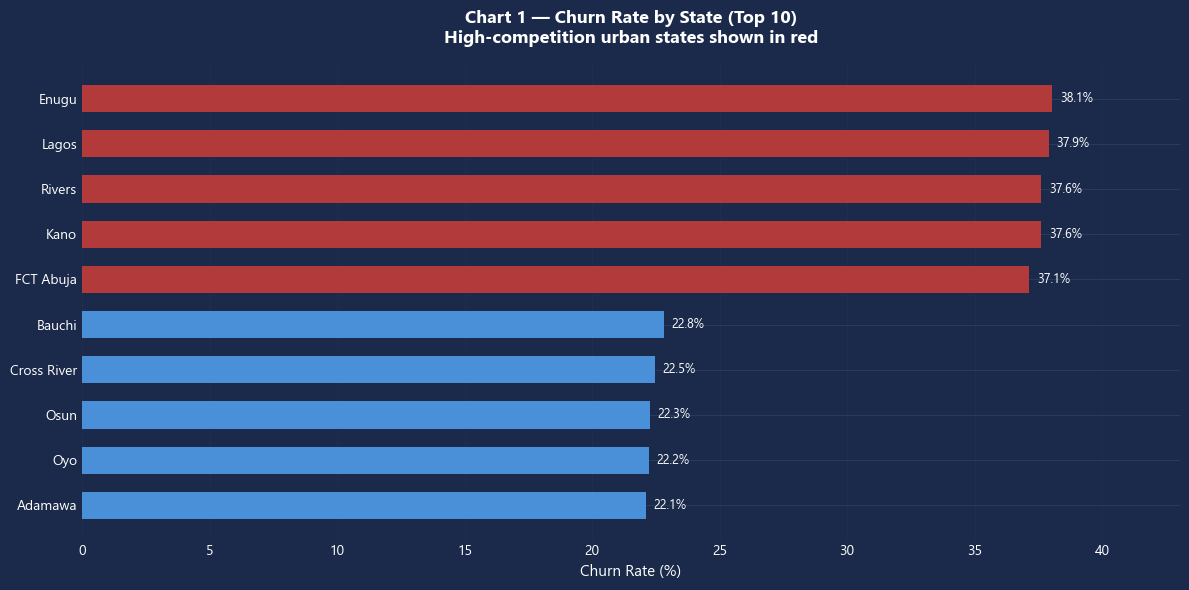

Chart 1 saved ✓


In [29]:
# Calculate churn rate per state
state_churn = (
    df.groupby('state')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'subscriber_count'})
    .reset_index()
)
state_churn['churn_rate_pct'] = state_churn['churn_rate'] * 100

# Sort and take top 10 by churn rate
top10_states = state_churn.sort_values('churn_rate_pct', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

# Colour bars: high-churn states in alert red, others in neutral blue
bar_colors = [
    ALERT_COLOR if state in HIGH_CHURN_STATES else NEUTRAL_COLOR
    for state in top10_states['state']
]

bars = ax.barh(
    top10_states['state'],
    top10_states['churn_rate_pct'],
    color=bar_colors,
    edgecolor='none',
    height=0.6
)

# Annotate each bar with the percentage
for bar, pct in zip(bars, top10_states['churn_rate_pct']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', ha='left',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 1 — Churn Rate by State (Top 10)\n'
    'High-competition urban states shown in red',
    fontsize=13, pad=15, fontweight='bold'
)
ax.invert_yaxis()
ax.set_xlim(0, top10_states['churn_rate_pct'].max() + 5)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart1_churn_by_state.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 1 saved ✓")


### CHART 2 — CHURN RATE BY TENURE BAND
 Business question: Are new subscribers or long-tenure subscribers more likely to churn?

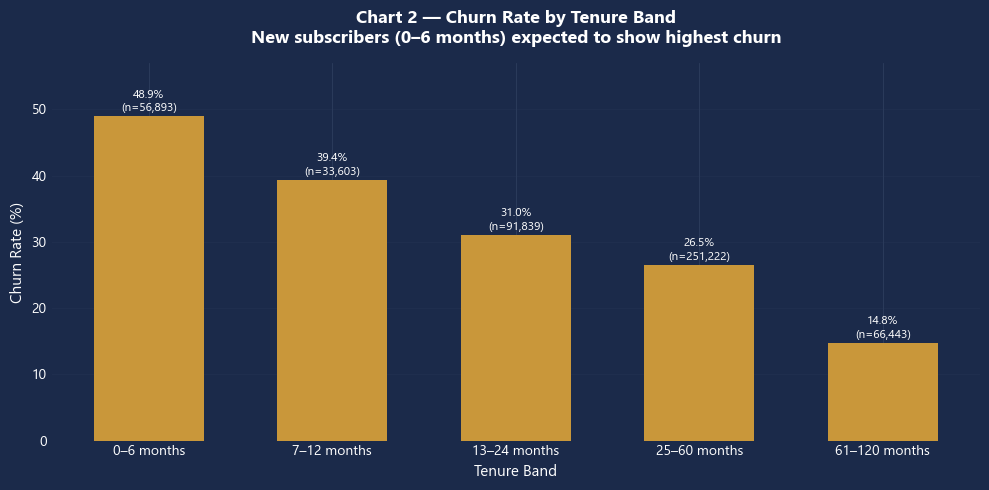

Chart 2 saved ✓


In [30]:
# Create tenure bands
tenure_bins   = [0, 6, 12, 24, 60, 120]
tenure_labels = ['0–6 months', '7–12 months', '13–24 months',
                 '25–60 months', '61–120 months']

df['tenure_band'] = pd.cut(
    df['tenure_months'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=True
)

tenure_churn = (
    df.groupby('tenure_band', observed=True)['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
)
tenure_churn['churn_rate_pct'] = tenure_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    tenure_churn['tenure_band'].astype(str),
    tenure_churn['churn_rate_pct'],
    color=ACCENT_COLOR,
    edgecolor='none',
    width=0.6
)

# Annotate bars
for bar, pct, cnt in zip(bars,
                          tenure_churn['churn_rate_pct'],
                          tenure_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=8.5
    )

ax.set_xlabel('Tenure Band', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 2 — Churn Rate by Tenure Band\n'
    'New subscribers (0–6 months) expected to show highest churn',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, tenure_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart2_churn_by_tenure.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 2 saved ✓")


### CHART 3 — CHURN RATE BY TARIFF PLAN
 Business question: Which MTN plans have a retention problem?

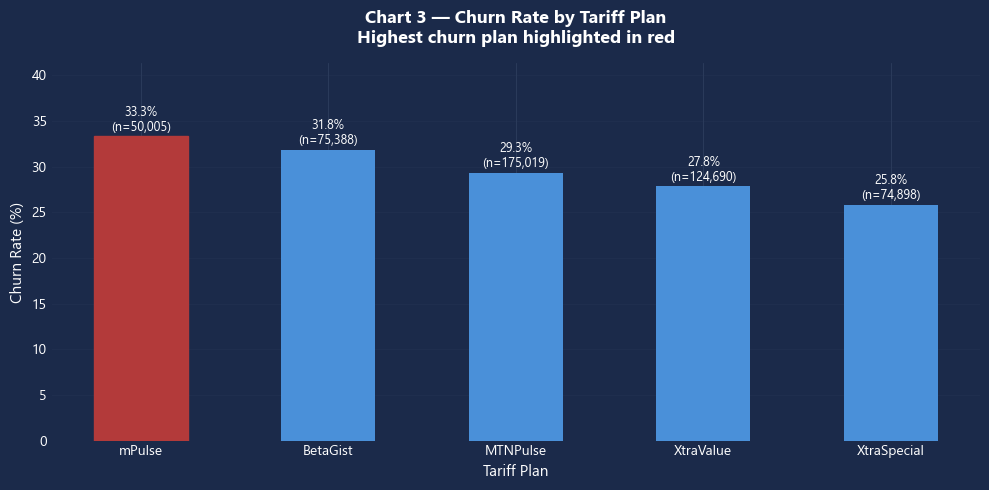

Chart 3 saved ✓


In [31]:
plan_churn = (
    df.groupby('tariff_plan')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
plan_churn['churn_rate_pct'] = plan_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    plan_churn['tariff_plan'],
    plan_churn['churn_rate_pct'],
    color=NEUTRAL_COLOR,
    edgecolor='none',
    width=0.5
)

# Highlight the highest churn plan in alert red
bars[0].set_color(ALERT_COLOR)

for bar, pct, cnt in zip(bars,
                          plan_churn['churn_rate_pct'],
                          plan_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Tariff Plan', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 3 — Churn Rate by Tariff Plan\n'
    'Highest churn plan highlighted in red',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, plan_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart3_churn_by_tariff.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 3 saved ✓")


### CHART 4 — CHURN RATE BY SUBSCRIBER SEGMENT
 Business question: Do Traditional and Digital subscribers
 churn at different rates?

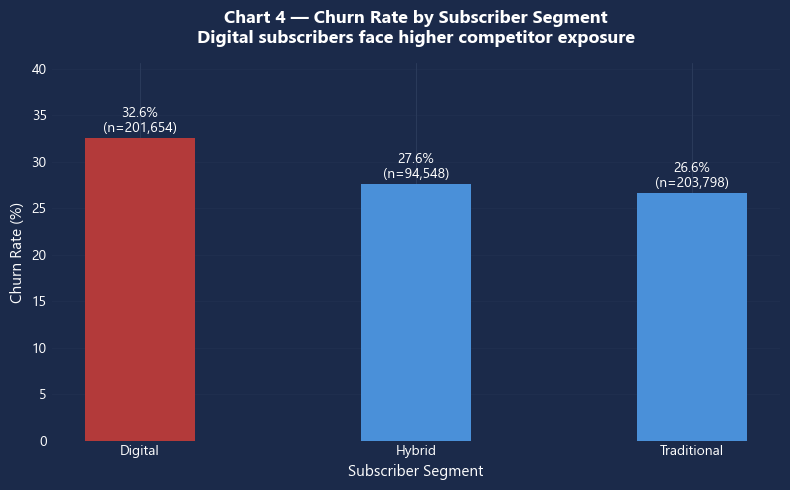

Chart 4 saved ✓


In [32]:
segment_churn = (
    df.groupby('subscriber_segment')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
segment_churn['churn_rate_pct'] = segment_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))

seg_colors = [ALERT_COLOR if seg == 'Digital' else NEUTRAL_COLOR
              for seg in segment_churn['subscriber_segment']]

bars = ax.bar(
    segment_churn['subscriber_segment'],
    segment_churn['churn_rate_pct'],
    color=seg_colors,
    edgecolor='none',
    width=0.4
)

for bar, pct, cnt in zip(bars,
                          segment_churn['churn_rate_pct'],
                          segment_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=10
    )

ax.set_xlabel('Subscriber Segment', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 4 — Churn Rate by Subscriber Segment\n'
    'Digital subscribers face higher competitor exposure',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, segment_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart4_churn_by_segment.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 4 saved ✓")


### CHART 5 — CHURN RATE BY BUNDLE TYPE
 Business question: Which bundle types are highest risk?

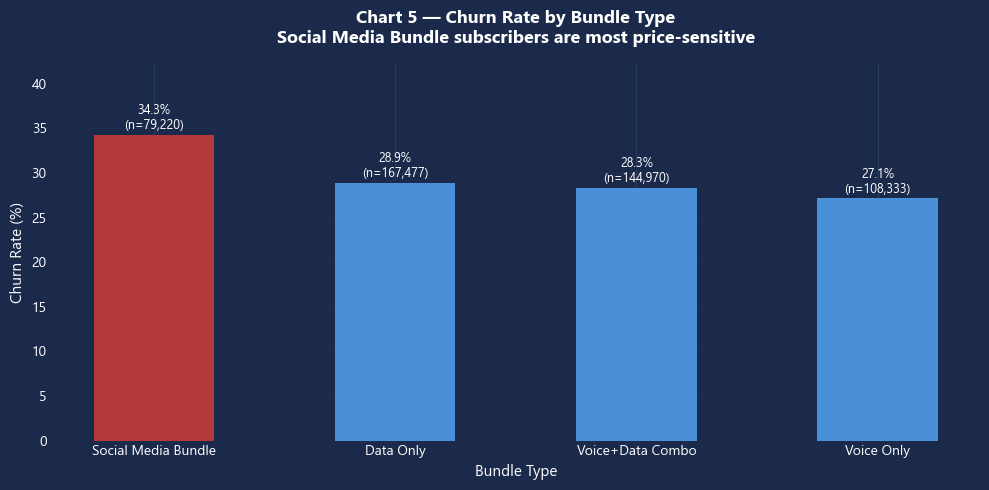

Chart 5 saved ✓


In [33]:
bundle_churn = (
    df.groupby('bundle_type')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
bundle_churn['churn_rate_pct'] = bundle_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bundle_colors = [
    ALERT_COLOR if b == 'Social Media Bundle' else NEUTRAL_COLOR
    for b in bundle_churn['bundle_type']
]

bars = ax.bar(
    bundle_churn['bundle_type'],
    bundle_churn['churn_rate_pct'],
    color=bundle_colors,
    edgecolor='none',
    width=0.5
)

for bar, pct, cnt in zip(bars,
                          bundle_churn['churn_rate_pct'],
                          bundle_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Bundle Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 5 — Churn Rate by Bundle Type\n'
    'Social Media Bundle subscribers are most price-sensitive',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, bundle_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart5_churn_by_bundle.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 5 saved ✓")


### CHART 6 — DAYS SINCE LAST RECHARGE: CHURNED VS RETAINED
 Business question: How different is recharge recency
 between subscribers who churned and those who stayed?

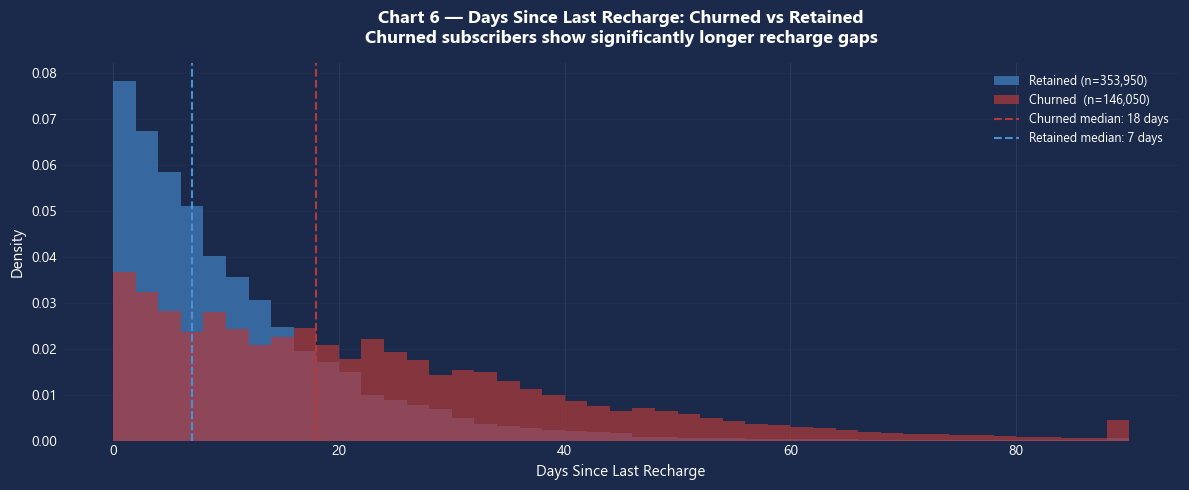

Chart 6 saved ✓


In [34]:
churned  = df[df['churn_label'] == 1]['days_since_last_recharge']
retained = df[df['churn_label'] == 0]['days_since_last_recharge']

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(retained, bins=45, alpha=0.6, color=NEUTRAL_COLOR,
        label=f'Retained (n={len(retained):,})',
        density=True, edgecolor='none')
ax.hist(churned,  bins=45, alpha=0.7, color=ALERT_COLOR,
        label=f'Churned  (n={len(churned):,})',
        density=True, edgecolor='none')

# Vertical lines for median of each group
ax.axvline(churned.median(),  color=ALERT_COLOR,  linestyle='--',
           linewidth=1.5, label=f'Churned median: {churned.median():.0f} days')
ax.axvline(retained.median(), color=NEUTRAL_COLOR, linestyle='--',
           linewidth=1.5, label=f'Retained median: {retained.median():.0f} days')

ax.set_xlabel('Days Since Last Recharge', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    'Chart 6 — Days Since Last Recharge: Churned vs Retained\n'
    'Churned subscribers show significantly longer recharge gaps',
    fontsize=13, pad=15, fontweight='bold'
)
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart6_recharge_recency_dist.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 6 saved ✓")


### CHART 7 — CORRELATION HEATMAP
 Business question: Which features move together?
 Are there redundant signals in our dataset?

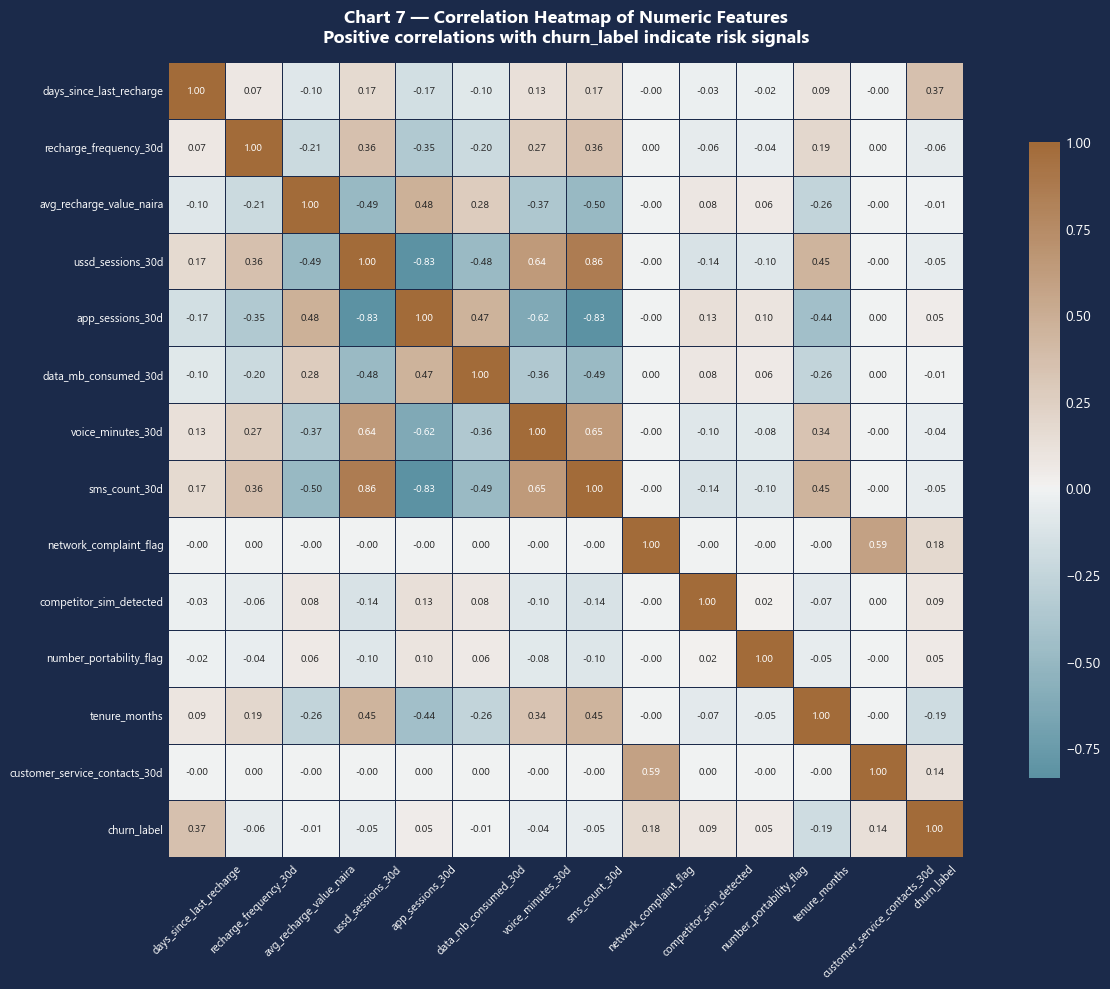

Chart 7 saved ✓


In [35]:
numeric_cols = [
    'days_since_last_recharge',
    'recharge_frequency_30d',
    'avg_recharge_value_naira',
    'ussd_sessions_30d',
    'app_sessions_30d',
    'data_mb_consumed_30d',
    'voice_minutes_30d',
    'sms_count_30d',
    'network_complaint_flag',
    'competitor_sim_detected',
    'number_portability_flag',
    'tenure_months',
    'customer_service_contacts_30d',
    'churn_label'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

# Custom diverging colormap — navy to gold
import matplotlib.colors as mcolors
cmap = sns.diverging_palette(220, 40, as_cmap=True)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap=cmap,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    linewidths=0.5,
    linecolor='#1B2A4A',
    square=True,
    cbar_kws={'shrink': 0.8}
)

ax.set_title(
    'Chart 7 — Correlation Heatmap of Numeric Features\n'
    'Positive correlations with churn_label indicate risk signals',
    fontsize=13, pad=15, fontweight='bold'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../outputs/chart7_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 7 saved ✓")


### CHART 8 — MONTHLY CHURN TREND (JAN 2022 – DEC 2024)
 Business question: Is churn getting better or worse
 over time? Are seasonal spikes visible?

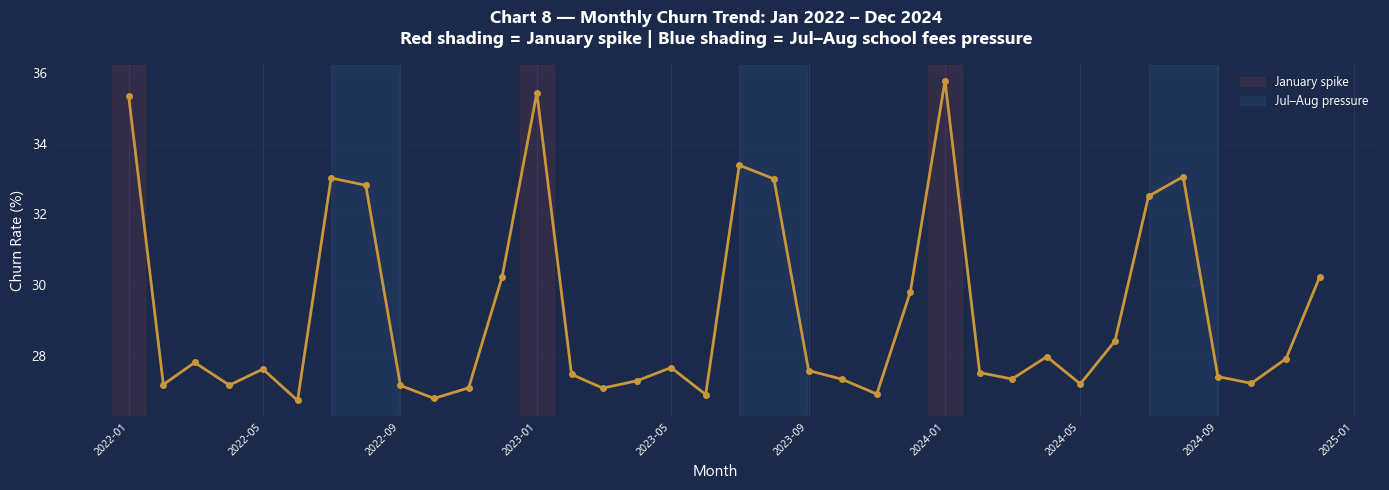

Chart 8 saved ✓

All charts generated and saved successfully!


In [36]:
# Calculate monthly churn rate
monthly_churn = (
    df.groupby('observation_month')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('observation_month')
)
monthly_churn['churn_rate_pct'] = monthly_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_churn['observation_month'],
    monthly_churn['churn_rate_pct'],
    color=ACCENT_COLOR,
    linewidth=2,
    marker='o',
    markersize=4,
    markerfacecolor=ACCENT_COLOR
)

# Shade January spikes (post-holiday)
for year in [2022, 2023, 2024]:
    jan_date = pd.Timestamp(f'{year}-01-01')
    ax.axvspan(
        jan_date - pd.Timedelta(days=15),
        jan_date + pd.Timedelta(days=15),
        alpha=0.15, color=ALERT_COLOR,
        label='January spike' if year == 2022 else ''
    )

# Shade July–August (school fees)
for year in [2022, 2023, 2024]:
    ax.axvspan(
        pd.Timestamp(f'{year}-07-01'),
        pd.Timestamp(f'{year}-08-31'),
        alpha=0.10, color=NEUTRAL_COLOR,
        label='Jul–Aug pressure' if year == 2022 else ''
    )

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 8 — Monthly Churn Trend: Jan 2022 – Dec 2024\n'
    'Red shading = January spike | Blue shading = Jul–Aug school fees pressure',
    fontsize=13, pad=15, fontweight='bold'
)
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/chart8_monthly_churn_trend.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 8 saved ✓")
print("\nAll charts generated and saved successfully!")

### EDA SUMMARY — KEY FINDINGS

In [37]:
print("\n" + "=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print(f"\n  Overall churn rate          : {df['churn_label'].mean()*100:.2f}%")
print(f"  Highest churn state         : {top10_states.iloc[0]['state']} "
      f"({top10_states.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Lowest tenure band churn    : {tenure_churn.sort_values('churn_rate_pct').iloc[0]['tenure_band']} "
      f"({tenure_churn.sort_values('churn_rate_pct').iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest tenure band churn   : {tenure_churn.sort_values('churn_rate_pct', ascending=False).iloc[0]['tenure_band']} "
      f"({tenure_churn.sort_values('churn_rate_pct', ascending=False).iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest churn tariff plan   : {plan_churn.iloc[0]['tariff_plan']} "
      f"({plan_churn.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest churn bundle type   : {bundle_churn.iloc[0]['bundle_type']} "
      f"({bundle_churn.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Digital vs Traditional churn: {dig_churn:.1f}% vs {trad_churn:.1f}%")
print(f"  Churned median recency      : {churned.median():.0f} days")
print(f"  Retained median recency     : {retained.median():.0f} days")
print(f"  Recency gap                 : {churned.median() - retained.median():.0f} days")

print("\n" + "=" * 60)
print("  All 8 charts saved to outputs/ folder")
print("=" * 60)


EDA SUMMARY — KEY FINDINGS

  Overall churn rate          : 29.21%
  Highest churn state         : Enugu (38.1%)
  Lowest tenure band churn    : 61–120 months (14.8%)
  Highest tenure band churn   : 0–6 months (48.9%)
  Highest churn tariff plan   : mPulse (33.3%)
  Highest churn bundle type   : Social Media Bundle (34.3%)
  Digital vs Traditional churn: 32.6% vs 26.6%
  Churned median recency      : 18 days
  Retained median recency     : 7 days
  Recency gap                 : 11 days

  All 8 charts saved to outputs/ folder


### CELL 6 — FEATURE ENGINEERING
 Builds 11 derived features from the 21 raw columns.

In [ ]:
# Features capture business logic the model cannot derive alone.
# All features are segment-aware where relevant.
#
# FEATURE LIST:
#   1.  recharge_recency_band     — ordinal activity tier
#   2.  engagement_score          — segment-aware composite 0-100
#   3.  revenue_at_risk_naira     — annualised revenue per subscriber
#   4.  risk_flag_composite       — segment-aware disengagement flag
#   5.  data_adoption_flag        — cross-service stickiness
#   6.  high_value_flag           — value + frequency threshold
#   7.  new_subscriber_flag       — tenure <= 6 months
#   8.  complaint_and_competitor  — double risk signal
#   9.  digital_risk_score        — digital channel decay 0-100
#   10. digital_channel_regression— digital subscriber on trad channel
#   11. hybrid_dual_silence       — both channels quiet simultaneously
#
# ENCODING:
#   Ordinal:      recharge_recency_band
#   One-hot:      subscriber_segment, tariff_plan,
#                 bundle_type, recharge_channel
#   Target encode:state (37 categories → 1 numeric column)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Work on a copy — never modify the original raw DataFrame
df_featured = df.copy()

print("=" * 60)
print("PHASE 2 — FEATURE ENGINEERING")
print("=" * 60)

# --------------------------------------------------------
# FEATURE 1 — RECHARGE RECENCY BAND
# Bins days_since_last_recharge into 4 ordered tiers.
# Ordinal because Active < Cooling < At Risk < Dormant
# is a meaningful progression — not just different categories.
# --------------------------------------------------------

print("\n[FEATURE 1] Recharge Recency Band")

recency_bins   = [-1, 7, 14, 21, 90]
recency_labels = ['Active', 'Cooling', 'At Risk', 'Dormant']

df_featured['recharge_recency_band'] = pd.cut(
    df_featured['days_since_last_recharge'],
    bins=recency_bins,
    labels=recency_labels
)

# Ordinal encoding: Active=0, Cooling=1, At Risk=2, Dormant=3
recency_order = {'Active': 0, 'Cooling': 1, 'At Risk': 2, 'Dormant': 3}
df_featured['recharge_recency_encoded'] = (
    df_featured['recharge_recency_band'].map(recency_order)
)

band_dist = df_featured['recharge_recency_band'].value_counts()
print(f"  Distribution:")
for label in recency_labels:
    cnt = band_dist.get(label, 0)
    pct = cnt / len(df_featured) * 100
    print(f"    {label:<10}: {cnt:>8,}  ({pct:.1f}%)")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 2 — ENGAGEMENT SCORE (segment-aware)
# Traditional: USSD, voice, SMS, recharge frequency
# Digital:     app, data, recharge value, frequency
# Hybrid:      50% traditional + 50% digital
# All normalised against realistic engaged benchmarks.
# Scaled to 0-100 after calculation.
# --------------------------------------------------------

print("\n[FEATURE 2] Engagement Score (segment-aware)")

# Segment boolean masks
is_trad = df_featured['subscriber_segment'] == 'Traditional'
is_dig  = df_featured['subscriber_segment'] == 'Digital'
is_hyb  = df_featured['subscriber_segment'] == 'Hybrid'

# Normalised components — clipped to 0-1
ussd_n  = np.clip(df_featured['ussd_sessions_30d']       / 35,   0, 1)
app_n   = np.clip(df_featured['app_sessions_30d']         / 15,   0, 1)
data_n  = np.clip(df_featured['data_mb_consumed_30d']     / 8000, 0, 1)
voice_n = np.clip(df_featured['voice_minutes_30d']        / 350,  0, 1)
sms_n   = np.clip(df_featured['sms_count_30d']            / 28,   0, 1)
freq_n  = np.clip(df_featured['recharge_frequency_30d']   / 6,    0, 1)
val_n   = np.clip(df_featured['avg_recharge_value_naira'] / 1500, 0, 1)

# Traditional engagement score
trad_score = (
    ussd_n  * 0.40 +
    voice_n * 0.35 +
    sms_n   * 0.15 +
    freq_n  * 0.10
)

# Digital engagement score
dig_score = (
    app_n  * 0.35 +
    data_n * 0.35 +
    val_n  * 0.15 +
    freq_n * 0.15
)

# Hybrid = 50/50 blend
hyb_score = (trad_score * 0.50) + (dig_score * 0.50)

# Assign score based on inferred segment
raw_score = np.where(
    is_trad, trad_score,
    np.where(is_dig, dig_score, hyb_score)
)

# Scale to 0-100 and clip
df_featured['engagement_score'] = np.clip(
    raw_score * 100, 0, 100
).round(2)

print(f"  Mean engagement score  : "
      f"{df_featured['engagement_score'].mean():.2f}")
print(f"  Traditional mean score : "
      f"{df_featured.loc[is_trad, 'engagement_score'].mean():.2f}")
print(f"  Digital mean score     : "
      f"{df_featured.loc[is_dig,  'engagement_score'].mean():.2f}")
print(f"  Hybrid mean score      : "
      f"{df_featured.loc[is_hyb,  'engagement_score'].mean():.2f}")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 3 — REVENUE AT RISK (NAIRA)
# avg_recharge_value × recharge_frequency × 12
# Annualised revenue this subscriber represents to MTN.
# This is a BUSINESS PRIORITISATION signal — not a churn
# predictor. Drives intervention strategy in Power BI.
# --------------------------------------------------------

print("\n[FEATURE 3] Revenue at Risk (Naira)")

df_featured['revenue_at_risk_naira'] = (
    df_featured['avg_recharge_value_naira'] *
    df_featured['recharge_frequency_30d'] *
    12
).round(2)

total_rev = df_featured['revenue_at_risk_naira'].sum()
mean_rev  = df_featured['revenue_at_risk_naira'].mean()

print(f"  Mean annual revenue per subscriber : ₦{mean_rev:,.0f}")
print(f"  Total portfolio revenue at risk    : "
      f"₦{total_rev/1e9:.2f}B")
print(f"  Min  : ₦{df_featured['revenue_at_risk_naira'].min():,.0f}")
print(f"  Max  : ₦{df_featured['revenue_at_risk_naira'].max():,.0f}")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 4 — RISK FLAG COMPOSITE (segment-aware)
# Thresholds calibrated to segment behaviour distributions.
# Traditional USSD avg=30 — threshold set at 10 (not 5)
# Digital app avg=12 — threshold set at 3 (not 2)
# Hybrid: both channels checked at raised thresholds
# --------------------------------------------------------

print("\n[FEATURE 4] Risk Flag Composite (segment-aware)")

trad_risk = (
    is_trad &
    (df_featured['days_since_last_recharge'] > 21) &
    (df_featured['recharge_frequency_30d']   < 3) &
    (df_featured['ussd_sessions_30d']        < 10)
)

dig_risk = (
    is_dig &
    (df_featured['days_since_last_recharge'] > 21) &
    (df_featured['recharge_frequency_30d']   < 3) &
    (df_featured['app_sessions_30d']         < 3)
)

hyb_risk = (
    is_hyb &
    (df_featured['days_since_last_recharge'] > 21) &
    (df_featured['recharge_frequency_30d']   < 3) &
    (df_featured['ussd_sessions_30d']        < 10) &
    (df_featured['app_sessions_30d']         < 4)
)

df_featured['risk_flag_composite'] = (
    trad_risk | dig_risk | hyb_risk
).astype(int)

flag_count = df_featured['risk_flag_composite'].sum()
flag_pct   = flag_count / len(df_featured) * 100
flag_churn = df_featured[
    df_featured['risk_flag_composite'] == 1
]['churn_label'].mean() * 100

print(f"  Subscribers flagged    : {flag_count:,}  ({flag_pct:.1f}%)")
print(f"  Churn rate when flagged: {flag_churn:.1f}%")
print(f"  (vs overall {df_featured['churn_label'].mean()*100:.1f}%)")
print("  DONE ✓")


# --------------------------------------------------------
# FEATURE 5 — DATA ADOPTION FLAG
# 1 if data_mb_consumed_30d > 500
# Cross-service stickiness — data users churn less.
# Switching means disrupting streaming, WhatsApp, downloads.
# --------------------------------------------------------

print("\n[FEATURE 5] Data Adoption Flag")

df_featured['data_adoption_flag'] = (
    df_featured['data_mb_consumed_30d'] > 500
).astype(int)

adopt_count = df_featured['data_adoption_flag'].sum()
adopt_churn = df_featured[
    df_featured['data_adoption_flag'] == 1
]['churn_label'].mean() * 100
no_adopt_churn = df_featured[
    df_featured['data_adoption_flag'] == 0
]['churn_label'].mean() * 100

print(f"  Data adopters          : {adopt_count:,}  "
      f"({adopt_count/len(df_featured)*100:.1f}%)")
print(f"  Churn rate — adopters  : {adopt_churn:.1f}%")
print(f"  Churn rate — non-adopt : {no_adopt_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 6 — HIGH VALUE FLAG
# 1 if avg_recharge > ₦1,000 AND recharge_frequency > 8
# Both conditions required — high amount alone is not enough.
# A subscriber recharing ₦2,000 once is not high value.
# One recharing ₦1,200 ten times a month is.
# --------------------------------------------------------

print("\n[FEATURE 6] High Value Flag")

df_featured['high_value_flag'] = (
    (df_featured['avg_recharge_value_naira'] > 1000) &
    (df_featured['recharge_frequency_30d']   > 8)
).astype(int)

hv_count = df_featured['high_value_flag'].sum()
hv_churn = df_featured[
    df_featured['high_value_flag'] == 1
]['churn_label'].mean() * 100

print(f"  High value subscribers : {hv_count:,}  "
      f"({hv_count/len(df_featured)*100:.1f}%)")
print(f"  High value churn rate  : {hv_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 7 — NEW SUBSCRIBER FLAG
# 1 if tenure_months <= 6
# Binary flag for the highest-risk loyalty threshold.
# --------------------------------------------------------

print("\n[FEATURE 7] New Subscriber Flag")

df_featured['new_subscriber_flag'] = (
    df_featured['tenure_months'] <= 6
).astype(int)

new_count = df_featured['new_subscriber_flag'].sum()
new_churn = df_featured[
    df_featured['new_subscriber_flag'] == 1
]['churn_label'].mean() * 100

print(f"  New subscribers (<=6m) : {new_count:,}  "
      f"({new_count/len(df_featured)*100:.1f}%)")
print(f"  New subscriber churn   : {new_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 8 — COMPLAINT AND COMPETITOR
# 1 if network_complaint_flag = 1 AND competitor_sim = 1
# Most dangerous combination: unhappy AND evaluating exit.
# These are the highest-priority intervention targets.
# --------------------------------------------------------

print("\n[FEATURE 8] Complaint and Competitor")

df_featured['complaint_and_competitor'] = (
    (df_featured['network_complaint_flag']  == 1) &
    (df_featured['competitor_sim_detected'] == 1)
).astype(int)

cc_count = df_featured['complaint_and_competitor'].sum()
cc_churn = df_featured[
    df_featured['complaint_and_competitor'] == 1
]['churn_label'].mean() * 100

print(f"  Double risk subscribers: {cc_count:,}  "
      f"({cc_count/len(df_featured)*100:.1f}%)")
print(f"  Double risk churn rate : {cc_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 9 — DIGITAL RISK SCORE
# Thresholds calibrated to Digital/Hybrid distributions.
# app < 4:      catches meaningful low-app engagement
# data < 1000:  realistic low-data threshold for digital
# recharge < 500: below typical digital mass market value
# --------------------------------------------------------

print("\n[FEATURE 9] Digital Risk Score")

app_decay   = (df_featured['app_sessions_30d']        < 4).astype(float)
data_decay  = (df_featured['data_mb_consumed_30d']     < 1000).astype(float)
value_decay = (df_featured['avg_recharge_value_naira'] < 500).astype(float)

raw_digital_risk = (
    app_decay   * 0.40 +
    data_decay  * 0.40 +
    value_decay * 0.20
)

# Only apply to Digital and Hybrid — Traditional = 0
df_featured['digital_risk_score'] = np.where(
    is_trad,
    0.0,
    (raw_digital_risk * 100).round(2)
)

dig_risk_mean = df_featured.loc[
    ~is_trad, 'digital_risk_score'
].mean()

print(f"  Mean score (Dig+Hyb)   : {dig_risk_mean:.1f} / 100")
print(f"  Score = 0  (no decay)  : "
      f"{(df_featured['digital_risk_score'] == 0).sum():,}")
print(f"  Score = 100 (full decay): "
      f"{(df_featured['digital_risk_score'] == 100).sum():,}")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 10 — DIGITAL CHANNEL REGRESSION
# 1 if Digital subscriber using Agent or Scratch Card.
# Behavioural regression — reverting to traditional channels.
# Affects ~15% of Digital subscribers.
# --------------------------------------------------------

print("\n[FEATURE 10] Digital Channel Regression")

df_featured['digital_channel_regression'] = (
    is_dig &
    df_featured['recharge_channel'].isin(['Agent', 'Scratch Card'])
).astype(int)

dcr_count = df_featured['digital_channel_regression'].sum()
dcr_churn = df_featured[
    df_featured['digital_channel_regression'] == 1
]['churn_label'].mean() * 100 if dcr_count > 0 else 0

print(f"  Digital channel regression : {dcr_count:,}  "
      f"({dcr_count/len(df_featured)*100:.1f}%)")
print(f"  Regression churn rate      : {dcr_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# FEATURE 11 — HYBRID DUAL SILENCE
# Thresholds raised to match Hybrid behaviour distributions.
# Hybrid USSD avg=18 — silence threshold at 10
# Hybrid app avg=7   — silence threshold at 4
# Both channels must be quiet — one alone is code-switching
# --------------------------------------------------------

print("\n[FEATURE 11] Hybrid Dual Silence")

df_featured['hybrid_dual_silence'] = (
    is_hyb &
    (df_featured['ussd_sessions_30d']        < 10) &
    (df_featured['app_sessions_30d']          < 4) &
    (df_featured['days_since_last_recharge'] > 14)
).astype(int)

hds_count = df_featured['hybrid_dual_silence'].sum()
hds_churn = df_featured[
    df_featured['hybrid_dual_silence'] == 1
]['churn_label'].mean() * 100 if hds_count > 0 else 0

print(f"  Hybrid dual silence    : {hds_count:,}  "
      f"({hds_count/len(df_featured)*100:.1f}%)")
print(f"  Dual silence churn rate: {hds_churn:.1f}%")
print("  DONE ✓")

# --------------------------------------------------------
# ENCODING SECTION
# --------------------------------------------------------

print("\n" + "=" * 60)
print("ENCODING")
print("=" * 60)

# --------------------------------------------------------
# ENCODING 1 — ORDINAL: recharge_recency_band
# Already encoded in Feature 1 as recharge_recency_encoded
# --------------------------------------------------------

print("\n[ENCODING 1] Ordinal — recharge_recency_band")
print(f"  Mapping: Active=0, Cooling=1, At Risk=2, Dormant=3")
print(f"  Column created: recharge_recency_encoded ✓")

# --------------------------------------------------------
# ENCODING 2 — ONE-HOT: subscriber_segment
# 3 categories: Traditional, Digital, Hybrid
# drop_first=True drops Traditional (baseline)
# --------------------------------------------------------

print("\n[ENCODING 2] One-Hot — subscriber_segment")

segment_dummies = pd.get_dummies(
    df_featured['subscriber_segment'],
    prefix='segment',
    drop_first=True,
    dtype=int
)
df_featured = pd.concat([df_featured, segment_dummies], axis=1)
print(f"  Columns created: {list(segment_dummies.columns)}")
print("  DONE ✓")

# --------------------------------------------------------
# ENCODING 3 — ONE-HOT: tariff_plan
# 5 categories: drop_first=True drops BetaGist (baseline)
# --------------------------------------------------------

print("\n[ENCODING 3] One-Hot — tariff_plan")

tariff_dummies = pd.get_dummies(
    df_featured['tariff_plan'],
    prefix='tariff',
    drop_first=True,
    dtype=int
)
df_featured = pd.concat([df_featured, tariff_dummies], axis=1)
print(f"  Columns created: {list(tariff_dummies.columns)}")
print("  DONE ✓")

# --------------------------------------------------------
# ENCODING 4 — ONE-HOT: bundle_type
# 4 categories: drop_first=True drops Data Only (baseline)
# --------------------------------------------------------

print("\n[ENCODING 4] One-Hot — bundle_type")

bundle_dummies = pd.get_dummies(
    df_featured['bundle_type'],
    prefix='bundle',
    drop_first=True,
    dtype=int
)
df_featured = pd.concat([df_featured, bundle_dummies], axis=1)
print(f"  Columns created: {list(bundle_dummies.columns)}")
print("  DONE ✓")

# --------------------------------------------------------
# ENCODING 5 — ONE-HOT: recharge_channel
# 5 categories: drop_first=True drops Agent (baseline)
# --------------------------------------------------------

print("\n[ENCODING 5] One-Hot — recharge_channel")

channel_dummies = pd.get_dummies(
    df_featured['recharge_channel'],
    prefix='channel',
    drop_first=True,
    dtype=int
)
df_featured = pd.concat([df_featured, channel_dummies], axis=1)
print(f"  Columns created: {list(channel_dummies.columns)}")
print("  DONE ✓")

# --------------------------------------------------------
# ENCODING 6 — TARGET ENCODE: state
# Replace each state with its mean churn rate.
# Why: 37 states → one-hot adds 36 columns = dimensionality
# explosion. Target encoding captures geographic churn
# signal in a single numeric column.
#
# IMPORTANT: Target encoding must be fit on TRAINING DATA
# only to prevent data leakage. Here we compute on the full
# dataset for EDA purposes — in Phase 3 we will recompute
# on training data only before modelling.
# --------------------------------------------------------

print("\n[ENCODING 6] Target Encode — state")
print("  NOTE: Full-dataset encoding for EDA only.")
print("  Will be recomputed on training data in Phase 3")
print("  to prevent data leakage.")

state_churn_map = (
    df_featured.groupby('state')['churn_label']
    .mean()
    .to_dict()
)

df_featured['state_churn_rate'] = (
    df_featured['state'].map(state_churn_map)
).round(4)

print(f"  Highest churn state encoding: "
      f"{max(state_churn_map, key=state_churn_map.get)} = "
      f"{max(state_churn_map.values()):.4f}")
print(f"  Lowest churn state encoding:  "
      f"{min(state_churn_map, key=state_churn_map.get)} = "
      f"{min(state_churn_map.values()):.4f}")
print("  DONE ✓")

# --------------------------------------------------------
# FINAL SUMMARY — FEATURE ENGINEERING COMPLETE
# --------------------------------------------------------

original_cols  = 21
new_feature_cols = 11
encoded_cols   = (
    len(segment_dummies.columns) +
    len(tariff_dummies.columns) +
    len(bundle_dummies.columns) +
    len(channel_dummies.columns) +
    2  # recharge_recency_encoded + state_churn_rate
)

print("\n" + "=" * 60)
print("FEATURE ENGINEERING — SUMMARY")
print("=" * 60)
print(f"  Original columns         : {original_cols}")
print(f"  New engineered features  : {new_feature_cols}")
print(f"  New encoded columns      : {encoded_cols}")
print(f"  Total columns in df_featured: {df_featured.shape[1]}")
print(f"  Rows unchanged           : {df_featured.shape[0]:,}")
print("=" * 60)

# Verify no nulls introduced by feature engineering
new_nulls = df_featured.isnull().sum().sum()
print(f"\n  Null check after engineering: {new_nulls} nulls")
assert new_nulls == 0, \
    f"FAIL: Feature engineering introduced {new_nulls} nulls"
print("  NULL CHECK PASSED ✓")
print("=" * 60)
print("  df_featured ready for Phase 3 — Imbalance Handling")
print("=" * 60)

PHASE 2 — FEATURE ENGINEERING

[FEATURE 1] Recharge Recency Band
  Distribution:
    Active    :  215,447  (43.1%)
    Cooling   :  109,122  (21.8%)
    At Risk   :   66,430  (13.3%)
    Dormant   :  109,001  (21.8%)
  DONE ✓

[FEATURE 2] Engagement Score (segment-aware)
  Mean engagement score  : 68.90
  Traditional mean score : 80.29
  Digital mean score     : 64.78
  Hybrid mean score      : 53.13
  DONE ✓

[FEATURE 3] Revenue at Risk (Naira)
  Mean annual revenue per subscriber : ₦41,355
  Total portfolio revenue at risk    : ₦20.68B
  Min  : ₦0
  Max  : ₦720,000
  DONE ✓

[FEATURE 4] Risk Flag Composite (segment-aware)
  Subscribers flagged    : 85  (0.0%)
  Churn rate when flagged: 61.2%
  (vs overall 29.2%)
  DONE ✓

[FEATURE 5] Data Adoption Flag
  Data adopters          : 313,816  (62.8%)
  Churn rate — adopters  : 30.2%
  Churn rate — non-adopt : 27.5%
  DONE ✓

[FEATURE 6] High Value Flag
  High value subscribers : 3,388  (0.7%)
  High value churn rate  : 25.9%
  DONE ✓

[FE